In [1]:
import pandas as pd

df = pd.read_csv("SeoulBikeData.csv")

display (df.head())

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01-12-17,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01-12-17,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01-12-17,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01-12-17,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01-12-17,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [3]:
summary_satistics = df.describe()

display(summary_satistics)

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [4]:
missing_values = df.isnull().sum()

print ("Missing values for each variable: ")
display(missing_values)

print ("Total missing values: ")
print(missing_values.sum())

Missing values for each variable: 


Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

Total missing values: 
0


In [5]:
duplicate_count = df.duplicated().sum()

print ("Number of duplicate records:")
print (duplicate_count)

Number of duplicate records:
0


In [6]:
print (df.dtypes)

Date                          object
Rented Bike Count              int64
Hour                           int64
Temperature(°C)              float64
Humidity(%)                    int64
Wind speed (m/s)             float64
Visibility (10m)               int64
Dew point temperature(°C)    float64
Solar Radiation (MJ/m2)      float64
Rainfall(mm)                 float64
Snowfall (cm)                float64
Seasons                       object
Holiday                       object
Functioning Day               object
dtype: object


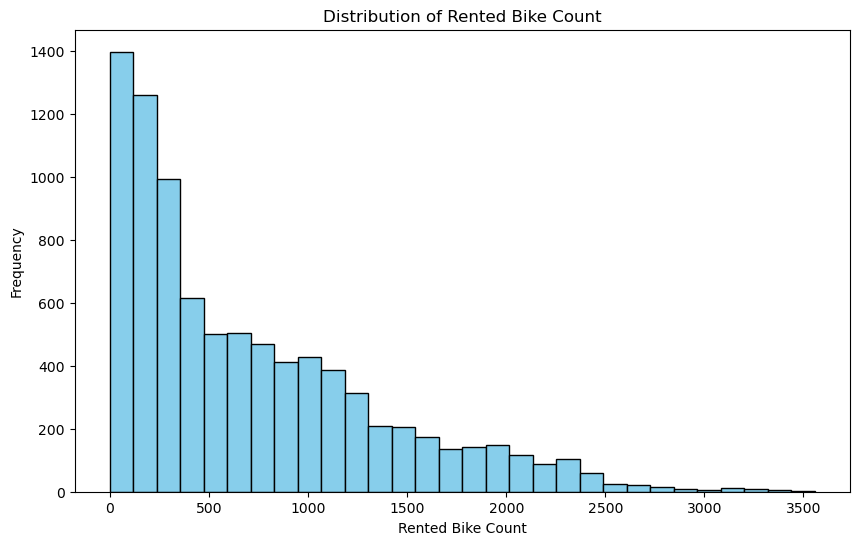

In [7]:
import matplotlib.pyplot as plt

plt.figure (figsize = (10, 6))

plt.hist(
    df["Rented Bike Count"],
    bins = 30,
    color = "skyblue",
    edgecolor = "black"
)

plt.title("Distribution of Rented Bike Count")
plt.xlabel("Rented Bike Count")
plt.ylabel("Frequency")

plt.show()

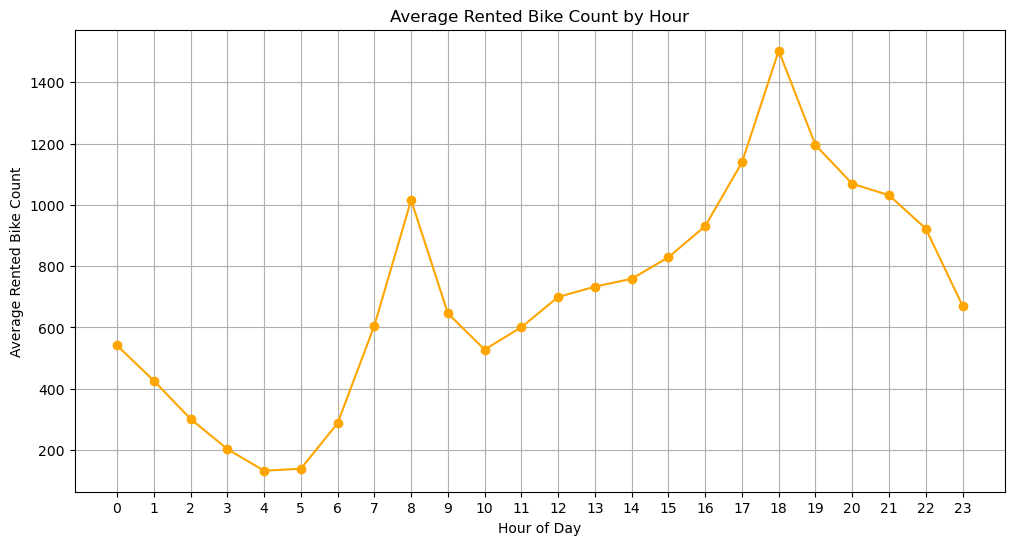

In [8]:
hourly_demand = (
    df.groupby("Hour") ["Rented Bike Count"]
        .mean()
        )

plt.figure (figsize = (12, 6))

plt.plot(
    hourly_demand.index,
    hourly_demand.values,
    marker = "o",
    color = "orange"
)

plt.title("Average Rented Bike Count by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rented Bike Count")

plt.xticks(range(24))
plt.grid(True)

plt.show()

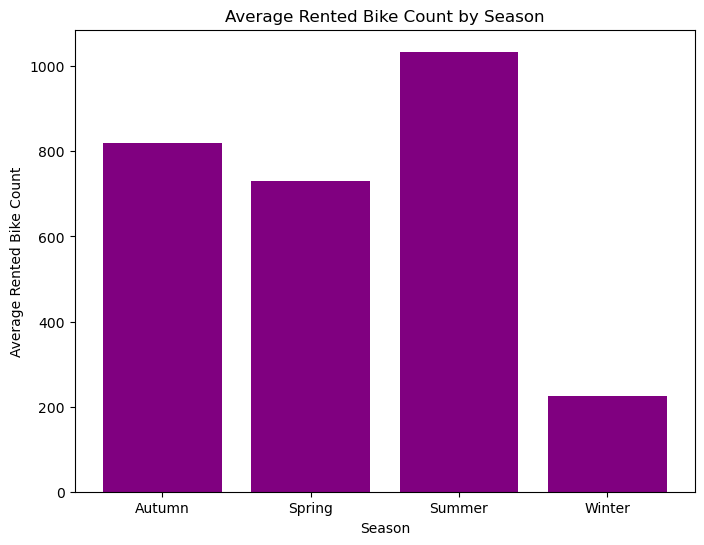

In [9]:
season_demand = (
    df.groupby("Seasons") ["Rented Bike Count"]
    .mean()
)

plt.figure (figsize = (8, 6))

plt.bar(
    season_demand.index,
    season_demand.values,
    color = "purple"
)

plt.title("Average Rented Bike Count by Season")
plt.xlabel("Season")
plt.ylabel("Average Rented Bike Count")

plt.show()

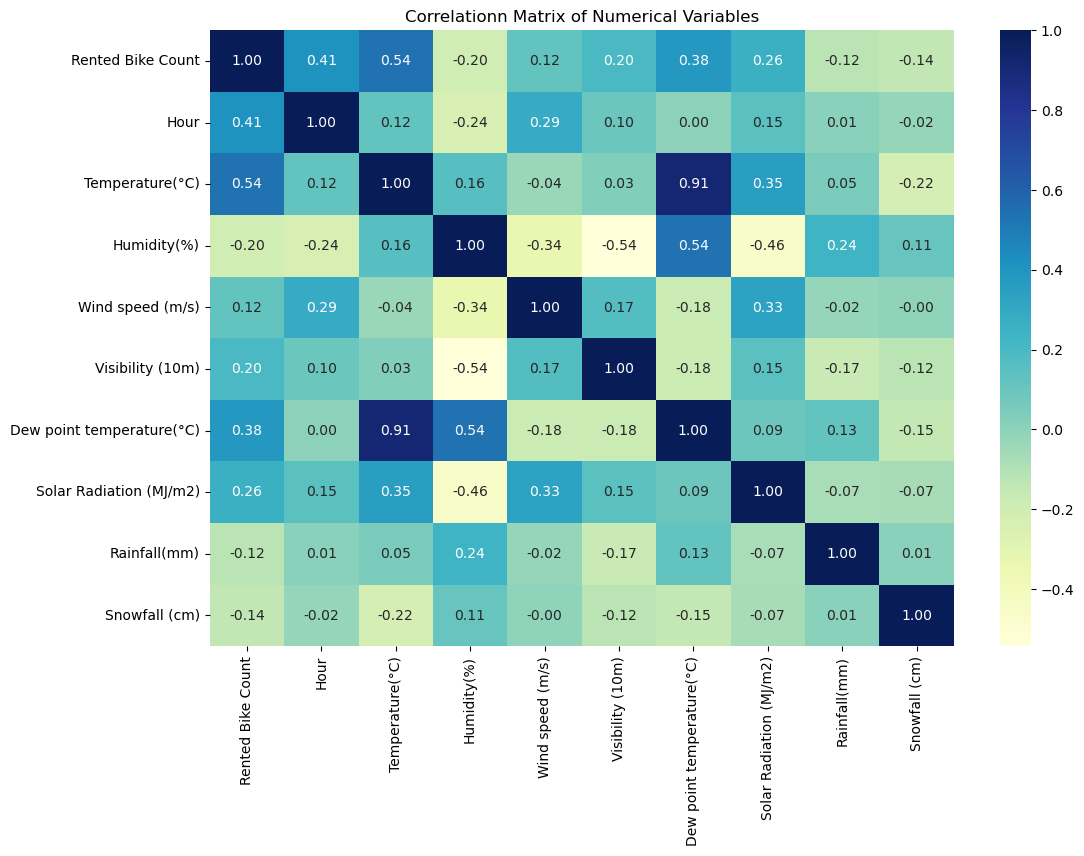

In [10]:
import seaborn as sns

numerical_data = df.select_dtypes(
    include = "number"
)

correlation_matrix = numerical_data.corr()

plt.figure (figsize = (12, 8))

sns.heatmap(
    correlation_matrix,
    annot = True,
    cmap = "YlGnBu",
    fmt = ".2f"
)

plt.title("Correlationn Matrix of Numerical Variables")

plt.show()

In [11]:
target_correlation = (
    correlation_matrix ["Rented Bike Count"]
    .sort_values (ascending = False)
)

print ("Correlation with Rented Bike Count: ")
display (target_correlation)

Correlation with Rented Bike Count: 


Rented Bike Count            1.000000
Temperature(°C)              0.538558
Hour                         0.410257
Dew point temperature(°C)    0.379788
Solar Radiation (MJ/m2)      0.261837
Visibility (10m)             0.199280
Wind speed (m/s)             0.121108
Rainfall(mm)                -0.123074
Snowfall (cm)               -0.141804
Humidity(%)                 -0.199780
Name: Rented Bike Count, dtype: float64

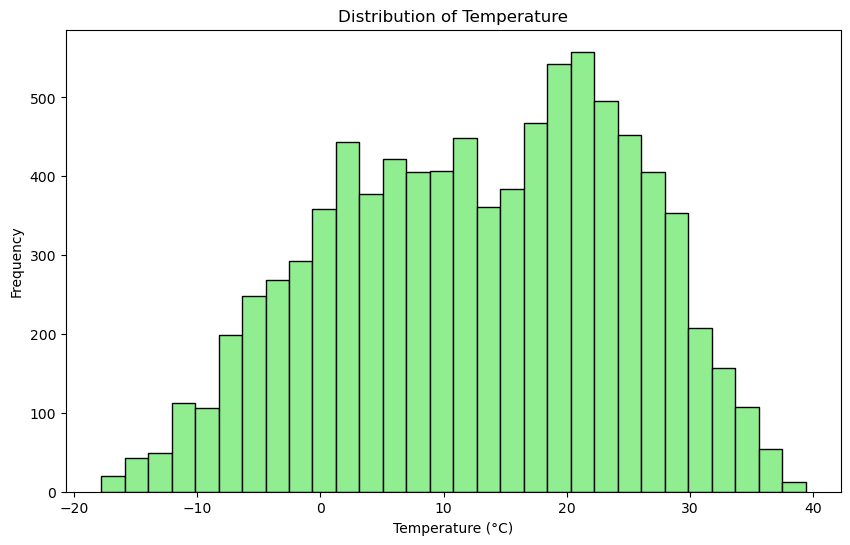

In [12]:
plt.figure (figsize = (10, 6))

plt.hist(
    df ["Temperature(°C)"],
    bins = 30,
    color = "lightgreen",
    edgecolor = "black"
)

plt.title("Distribution of Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

In [13]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nNumber of duplicated rows:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [15]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)

datetime64[ns]


In [16]:
print(df[["Date", "Hour"]].head())

        Date  Hour
0 2017-01-12     0
1 2017-01-12     1
2 2017-01-12     2
3 2017-01-12     3
4 2017-01-12     4


In [17]:
df["DayOfWeek"] = df["Date"].dt.dayofweek

df["Month"] = df["Date"].dt.month

df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

display(df[["Date", "DayOfWeek", "Month", "IsWeekend"]].head())

,Date,DayOfWeek,Month,IsWeekend
0,2017-01-12,3,1,0
1,2017-01-12,3,1,0
2,2017-01-12,3,1,0
3,2017-01-12,3,1,0
4,2017-01-12,3,1,0


In [18]:
categorical_features = [
    "Seasons",
    "Holiday",
    "Functioning Day"
]

numerical_features = [
    "Hour",
    "Temperature(°C)",
    "Humidity(%)",
    "Wind speed (m/s)",
    "Visibility (10m)",
    "Dew point temperature(°C)",
    "Solar Radiation (MJ/m2)",
    "Rainfall(mm)",
    "Snowfall (cm)",
    "DayOfWeek",
    "Month",
    "IsWeekend"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Seasons', 'Holiday', 'Functioning Day']

Numerical features:
['Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'DayOfWeek', 'Month', 'IsWeekend']


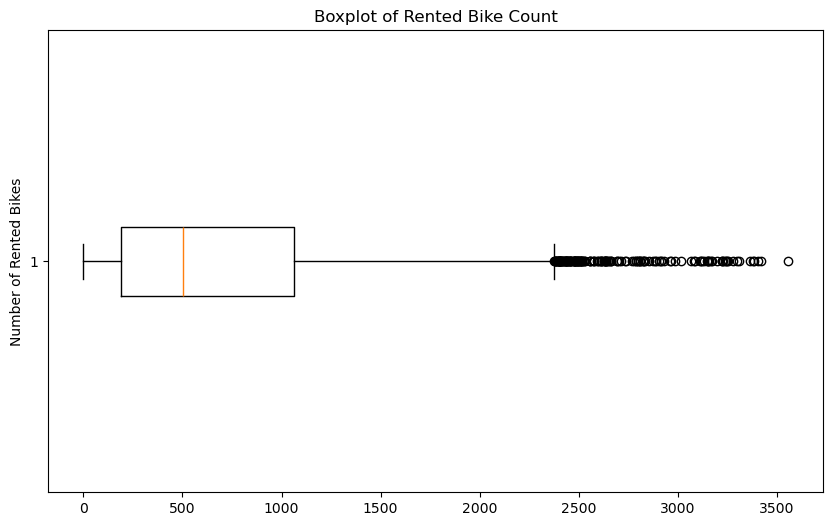

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.boxplot(df["Rented Bike Count"], vert = False)

plt.title("Boxplot of Rented Bike Count")
plt.ylabel("Number of Rented Bikes")

plt.show()

In [20]:
Q1 = df["Rented Bike Count"].quantile(0.25)
Q3 = df["Rented Bike Count"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Rented Bike Count"] < lower_bound) |
    (df["Rented Bike Count"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of potential outliers:", len(outliers))

Q1: 191.0
Q3: 1065.25
IQR: 874.25
Lower Bound: -1120.375
Upper Bound: 2376.625
Number of potential outliers: 158


In [21]:
y = df["Rented Bike Count"]

X = df[
    [
        "Date",
        "Rented Bike Count",
        "Hour",
        "Temperature(°C)",
        "Humidity(%)",
        "Wind speed (m/s)",
        "Visibility (10m)",
        "Dew point temperature(°C)",
        "Solar Radiation (MJ/m2)",
        "Rainfall(mm)",
        "Snowfall (cm)",
        "Seasons",
        "Holiday",
        "Functioning Day"
    ]
]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (8760, 14)
y shape: (8760,)


In [22]:
df = df.sort_values(["Date", "Hour"]).reset_index(drop=True)

y = df["Rented Bike Count"]

X = df[
    [
        "Hour",
        "Temperature(°C)",
        "Humidity(%)",
        "Wind speed (m/s)",
        "Visibility (10m)",
        "Dew point temperature(°C)",
        "Solar Radiation (MJ/m2)",
        "Rainfall(mm)",
        "Snowfall (cm)",
        "Seasons",
        "Holiday",
        "Functioning Day",
        "DayOfWeek",
        "Month",
        "IsWeekend"
    ]
]

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (7008, 15)
Testing data: (1752, 15)


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

categorical_features = [
    "Seasons",
    "Holiday",
    "Functioning Day"
]

numerical_features = [
    "Hour",
    "Temperature(°C)",
    "Humidity(%)",
    "Wind speed (m/s)",
    "Visibility (10m)",
    "Dew point temperature(°C)",
    "Solar Radiation (MJ/m2)",
    "Rainfall(mm)",
    "Snowfall (cm)",
    "DayOfWeek",
    "Month",
    "IsWeekend"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Preprocessing setup completed.")

Preprocessing setup completed.


In [26]:
import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

# Convert Date
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Sort chronologically
df = df.sort_values(["Date", "Hour"]).reset_index(drop=True)

# Feature engineering
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Month"] = df["Date"].dt.month
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

# Target
target = "Rented Bike Count"

# Features
features = [
    "Hour",
    "Temperature(°C)",
    "Humidity(%)",
    "Wind speed (m/s)",
    "Visibility (10m)",
    "Dew point temperature(°C)",
    "Solar Radiation (MJ/m2)",
    "Rainfall(mm)",
    "Snowfall (cm)",
    "Seasons",
    "Holiday",
    "Functioning Day",
    "DayOfWeek",
    "Month",
    "IsWeekend"
]

X = df[features]
y = df[target]

# Chronological 80/20 split
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Numerical and categorical columns
numerical_features = [
    "Hour",
    "Temperature(°C)",
    "Humidity(%)",
    "Wind speed (m/s)",
    "Visibility (10m)",
    "Dew point temperature(°C)",
    "Solar Radiation (MJ/m2)",
    "Rainfall(mm)",
    "Snowfall (cm)",
    "DayOfWeek",
    "Month",
    "IsWeekend"
]

categorical_features = [
    "Seasons",
    "Holiday",
    "Functioning Day"
]

# Preprocessing for Linear Regression
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

linear_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("model", LinearRegression())
    ]
)

In [27]:
# Train Linear Regression
linear_model.fit(X_train, y_train)

print("Linear Regression training completed.")

Linear Regression training completed.


In [28]:
# Prediction
linear_train_pred = linear_model.predict(X_train)
linear_test_pred = linear_model.predict(X_test)

print("Linear Regression predictions generated.")

Linear Regression predictions generated.


In [29]:
# Evaluation function
def evaluate_model(model_name, y_train, train_pred, y_test, test_pred):

    train_mae = mean_absolute_error(y_train, train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    train_r2 = r2_score(y_train, train_pred)

    test_mae = mean_absolute_error(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_r2 = r2_score(y_test, test_pred)

    return {
        "Model": model_name,
        "Train MAE": train_mae,
        "Train RMSE": train_rmse,
        "Train R²": train_r2,
        "Test MAE": test_mae,
        "Test RMSE": test_rmse,
        "Test R²": test_r2
    }


linear_results = evaluate_model(
    "Linear Regression",
    y_train,
    linear_train_pred,
    y_test,
    linear_test_pred
)

print(linear_results)

{'Model': 'Linear Regression', 'Train MAE': 327.6871201184499, 'Train RMSE': np.float64(434.5702091632139), 'Train R²': 0.5562094202068648, 'Test MAE': 312.22055769332917, 'Test RMSE': np.float64(424.3488011065837), 'Test R²': 0.5161521294174507}


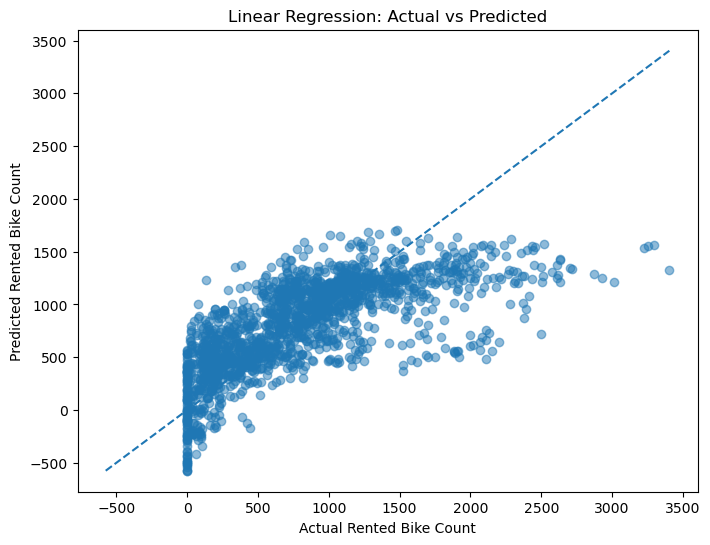

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, linear_test_pred, alpha=0.5)

min_value = min(y_test.min(), linear_test_pred.min())
max_value = max(y_test.max(), linear_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

In [31]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

tree_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]
)

In [32]:
tree_param_grid = {
    "model__max_depth": [5, 10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5]
}

tscv = TimeSeriesSplit(n_splits=5)

tree_grid = GridSearchCV(
    tree_model,
    tree_param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

print("Best Decision Tree parameters:")
print(tree_grid.best_params_)

Best Decision Tree parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}


In [33]:
tree_model_final = tree_grid.best_estimator_

In [34]:
tree_model_final.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
tree_train_pred = tree_model_final.predict(X_train)
tree_test_pred = tree_model_final.predict(X_test)

In [36]:
tree_results = evaluate_model(
    "Decision Tree Regression",
    y_train,
    tree_train_pred,
    y_test,
    tree_test_pred
)

print(tree_results)

{'Model': 'Decision Tree Regression', 'Train MAE': 130.80745080680015, 'Train RMSE': np.float64(215.8496438546954), 'Train R²': 0.890513430082391, 'Test MAE': 217.6906135505228, 'Test RMSE': np.float64(320.758215087536), 'Test R²': 0.7235488179546995}


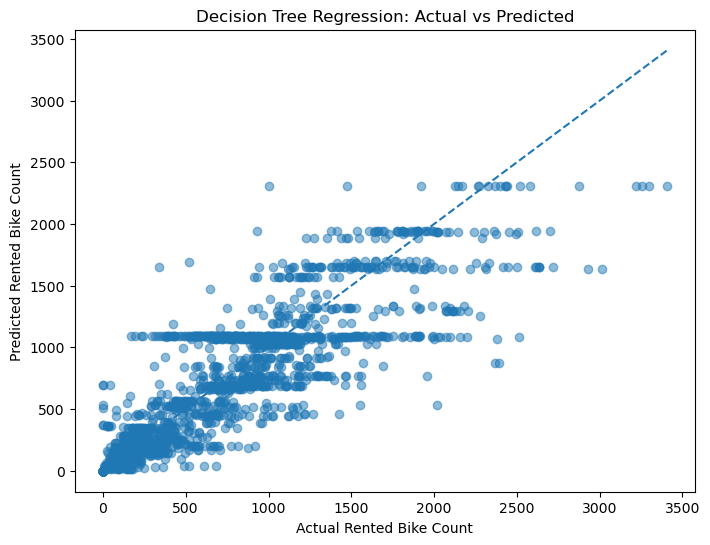

In [37]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, tree_test_pred, alpha=0.5)

min_value = min(y_test.min(), tree_test_pred.min())
max_value = max(y_test.max(), tree_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.title("Decision Tree Regression: Actual vs Predicted")

plt.show()

In [38]:
rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

rf_model = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [39]:
rf_param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": [1.0, "sqrt"]
}

rf_grid = GridSearchCV(
    rf_model,
    rf_param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print(rf_grid.best_params_)

{'model__max_depth': None, 'model__max_features': 1.0, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [40]:
rf_final = rf_model

In [41]:
rf_final.fit(X_train, y_train)

rf_train_pred = rf_final.predict(X_train)
rf_test_pred = rf_final.predict(X_test)

In [42]:
rf_results = evaluate_model(
    "Random Forest Regression",
    y_train,
    rf_train_pred,
    y_test,
    rf_test_pred
)

print(rf_results)

{'Model': 'Random Forest Regression', 'Train MAE': 44.26264269406392, 'Train RMSE': np.float64(75.62729255761275), 'Train R²': 0.9865595043932249, 'Test MAE': 183.02752283105022, 'Test RMSE': np.float64(276.4506799428563), 'Test R²': 0.794648348514951}


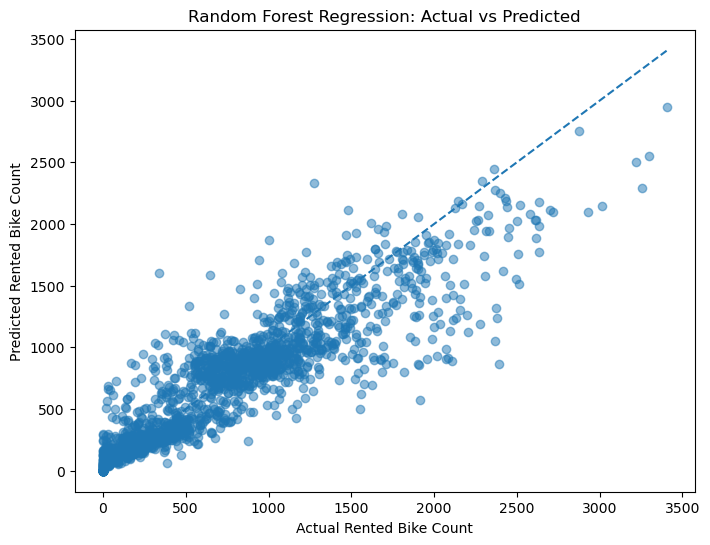

In [43]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_test_pred, alpha=0.5)

min_value = min(y_test.min(), rf_test_pred.min())
max_value = max(y_test.max(), rf_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.title("Random Forest Regression: Actual vs Predicted")

plt.show()

In [49]:
gb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

gb_model = Pipeline(
    steps=[
        ("preprocessor", gb_preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ]
)

gb_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [50]:
gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3, 5],
    "model__min_samples_leaf": [1, 2, 5]
}

gb_grid = GridSearchCV(
    gb_model,
    gb_param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting parameters:")
print(gb_grid.best_params_)

gb_final = gb_grid.best_estimator_

Best Gradient Boosting parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}


In [51]:
gb_final.fit(X_train, y_train)

gb_train_pred = gb_final.predict(X_train)
gb_test_pred = gb_final.predict(X_test)

In [52]:
gb_results = evaluate_model(
    "Gradient Boosting Regression",
    y_train,
    gb_train_pred,
    y_test,
    gb_test_pred
)

print(gb_results)

{'Model': 'Gradient Boosting Regression', 'Train MAE': 106.981426180822, 'Train RMSE': np.float64(165.01055449366692), 'Train R²': 0.9360144916633913, 'Test MAE': 180.67489686759376, 'Test RMSE': np.float64(269.8172211314839), 'Test R²': 0.8043849768791839}


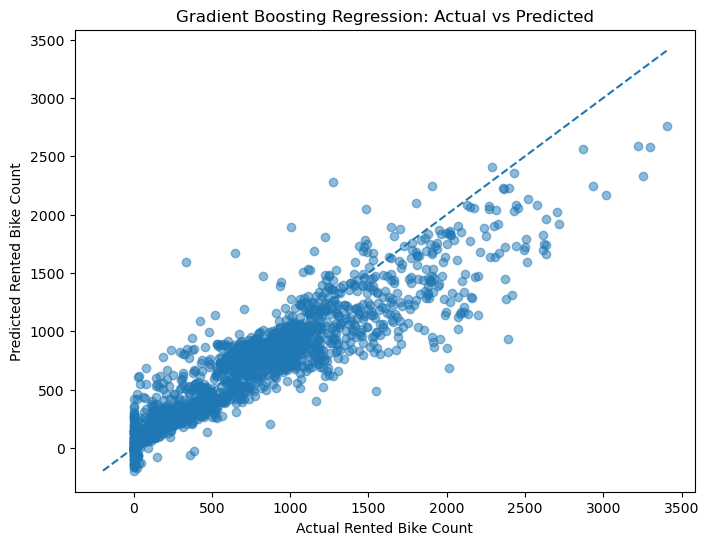

In [53]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, gb_test_pred, alpha=0.5)

min_value = min(y_test.min(), gb_test_pred.min())
max_value = max(y_test.max(), gb_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.title("Gradient Boosting Regression: Actual vs Predicted")

plt.show()